In [1]:
import numpy as np
from scipy.stats import norm
import math
import numpy as np
from scipy.optimize import minimize_scalar, minimize
from pathlib import Path
import time
from PIL import Image
import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = 'svg'

In [2]:
class JNDModel:
    
    def __init__(self, L_MIN = 0.1, L_MAX = 300, t = 1, phi_d_screen = 1e-3, p = 0.75):
        self.L_MIN = L_MIN
        self.L_MAX = L_MAX
        self.t = t # время экспозиции (наблюдения) объекта в секундах
        self.phi_d_screen = phi_d_screen # угловой размер пикселя на экране (в радианах)
        self.phi_d = phi_d_screen # угловой размер объекта (в радианах)
        self.p = p # требуемая вероятность обнаружения объекта
        self.L0 = 1e-6
    
    @classmethod
    def from_screen_params(cls, screen_diag_inch = 16, screen_width_px = 1920, screen_height_px = 1080, distance_m = 0.5,
                           l_gray = 60, **kwargs):
        '''
        Фабричный метод для инициализации JNDModel с рассчетом phi_d на основе параметров экрана
        '''
        diag_px = math.sqrt(screen_width_px ** 2 + screen_height_px ** 2)
        ppi = diag_px / screen_diag_inch
        
        pixel_size_m = 0.0254 / ppi # 1 дюйм = 0.0254 метра

        phi_d_screen = pixel_size_m / distance_m # считаем угловой размер пикселя на экране

        instance = cls(phi_d_screen=phi_d_screen, **kwargs)

        instance.screen_width_px = screen_width_px
        instance.screen_height_px = screen_height_px
        instance.ppi = ppi
        instance.l_gray = l_gray

        return instance

    def _K(self, lambd, b1 = 0.98, b2 = 0.1, lambd1 = 2e-2):
        lambd = np.asarray(lambd, dtype = np.float64)
        return np.where(lambd <= 1, b1 * (1 + lambd1 / lambd), lambd ** b2)
    
    def _A(self, La, a1 = 4.8e6, a2 = 7.1e3, a3 = 4.5e-4): # единицы измерения параметров a1, a2, a3: м ** 2 / кд
        '''
        Функция, характеризующая ослабление сигнала в зрительной системе в результате процесса яркостной адаптации 
        к однородному фону с яркостью La

        '''
        return 1 + (a1 * La) ** 0.5 + a2 * La * (1 + (a3 * La) ** 0.5) # формула 9.6
    
    def _Lambda(self, lambd):
        return lambd * self._K(lambd)
    
    def _eta(self, La, L3 = 1e6, L4 = 1, a4 = 600): # единицы измерения параметров L3: кд / м ** 2, L4: кд / м ** 2, a4: м ** 4 / кд ** 2
        '''
        Функция адаптации временных интервалов

        '''
        return 1 + L3 / (1 + a4 * La * (L4 + La)) # Формула 9.12
        
    def _C(self, La, t): # единицы измерения: c
        tao_min = 0.05 # минимальное значение времени инерции зрения
        T = t / (tao_min * self._eta(La)) # формула 9.7
        return 1 + 1 / T # Формула 9.10. При имплементации выбрал 1 вариант из статьи. Есть 2 вариант - формула 9.11: C = 1 / (1 - exp(-T))
    
    def _func_phi_1(self, La, c2 = 0.25, L1 = 10, L2 = 2.6e-5): # единицы измерения параметров L1, L2: кд / м ** 2
        return (1 + L1 / (L2 + La)) ** c2 # формула 9.4
    
    def _S(self, La, theta_1 = 6.1, a_d = 2, inf_phi_1 = 1):
        phi_0_min = 0.5 * (1 / 60) * (np.pi / 180) # phi_0_min = 0,5' - 1'
        phi_1 = self._func_phi_1(La)
        phi_0 = phi_1 * phi_0_min / inf_phi_1
        
        return (theta_1 * phi_0 / self.phi_d + 1.0) ** a_d # формула 9.2
    
    def _l(self, La):
        return self.L0 * self._A(La) # формула 9.5
    
    def _P(self, p, p_ref = 0.75):
        '''
        Пороговая функция вероятности обнаружения, в статье не описано что это за функция. 
        Решил взять отношение необходимых сдвигов распределения при которых площадь по графиком шума глаза + сигнала равна соотвественно p_ref и p

        p_ref - веротность, с котороый мы РЕАЛЬНО в экспериментах статьи видим разницу в измении на 1 уровень яркости
        p - веротность, с котороый мы хотим чтобы была видна разница в измении на 1 уровень яркости

        В статье p_ref = 0.75 не фигурирует, так что в экспериментах используется p = p_ref = 0.75, чтобы множитель 
        от функции P не вносил ничего в итоговую формулу (P = 1)

        '''
        return abs(norm.ppf(p) / norm.ppf(p_ref))

    def _D(self, L, La): # единицы измерения параметра L0: кд / м ** 2
        '''
        L0 - абсолютный световой порог - минимальное значение яркости, которое человек способен заметить

        A(La) - адаптационное ослабление сигнала, зависит от яркости адаптации, регулировка чувствительности 
        к яркости в зависимости от фона

        C(La, t) - временная обработка, зависит от времени экспозиции t и яркости адаптации

        Lambda(lambd) - амплитудная обработка, зависит от lambd - нормализованной разницой между яркостью объекта 
        и яркостью адаптации, описывает нелинейность вопсприятия

        S(La, phi_d) - пространственная обработка, учитывает угловой размер объекта (phi_d) и минимальный угол разрешения глаза (phi_0)

        P(p) - пороговая функция вероятности обнаружения, позволяет учесть вероятность с которой мы хотим видеть объект

        '''
        lambd = L / (10 ** 2 * self._l(La)) # формула 9.13
        return self.L0 * self._A(La) * self._C(La, self.t) * self._Lambda(lambd) * self._S(La) * self._P(self.p) # формула 9.16


    def find_La(self, L_matrix):
        EPS = 1e-12
        logL = np.log(np.maximum(L_matrix, EPS))
    
        # Границы можно расширить, если адаптация может лежать вне диапазона яркостей картинки.
        log_La_min = float(logL.min())
        log_La_max = float(logL.max())
    
        def S_score(L_matrix, start_La):
            numerator = self._D(L_matrix, start_La)
            denominator = self._D(L_matrix, L_matrix)
            return float(np.mean(np.log(numerator / denominator)))
        
        def objective_log_La(log_La):
            return S_score(L_matrix, math.exp(float(log_La)))
        
        result = minimize_scalar(
            objective_log_La,
            bounds=(log_La_min, log_La_max),
            method='bounded',
            options={'xatol': 1e-6},
        )
        
        log_La_star = float(result.x)
        self.La = math.exp(log_La_star)
        
        return self.La

    def find_La_with_background(self, L_patch, optimizer = 'minimize_scalar', target_width_cm = None):
        '''
        L_patch подается в оригинальном разрешении
        
        '''
        if (isinstance(L_patch, np.ndarray) and L_patch.size > 0 and L_patch.ndim == 2):
            h_patch_px, w_patch_px = L_patch.shape
            aspect_ratio = h_patch_px / w_patch_px

            if target_width_cm is None:
                target_w_px = w_patch_px
                target_h_px = h_patch_px
            else:
                target_w_px = int(np.round((target_width_cm / 2.54) * self.ppi))
                target_h_px = int(np.round(target_w_px * aspect_ratio))

            n_patch_screen = target_w_px * target_h_px

            scale = target_w_px / w_patch_px
            self.phi_d = scale * self.phi_d_screen
        else:
            n_patch_screen = 0
            self.phi_d = self.phi_d_screen

        n_total = self.screen_width_px * self.screen_height_px
        
        n_bg = n_total - n_patch_screen

        logL = np.log(np.maximum(L_patch, 1e-12))
        # log_La_min = float(min(logL.min(), np.log(self.l_gray)))
        # log_La_max = float(max(logL.max(), np.log(self.l_gray)))
        log_La_min = -3.0 # La = 0.05
        log_La_max = 6.0 # La = 403.43

        def objective_log_La(log_La):
            curr_La = math.exp(float(log_La))
        
            # Считаем для пикселей патча
            if L_patch.size > 0:
                num_patch = self._D(L_patch, curr_La)
                den_patch = self._D(L_patch, L_patch)
                sum_patch = (n_patch_screen / L_patch.size) * float(np.sum(np.log(num_patch / den_patch)))
            else:
                sum_patch = 0.0
            
            # 2. Для фона считаем одно число и умножаем на количество пикселей фона
            num_bg = self._D(self.l_gray, curr_La)
            den_bg = self._D(self.l_gray, self.l_gray)
            sum_bg = n_bg * math.log(num_bg / den_bg)
            
            return float((sum_patch + sum_bg) / n_total) # считаем фон и саму картинку равнозначными

        if optimizer == 'minimize_scalar':

            history_x = []
            history_loss = []

            def tracked_objective(log_la):
                loss = objective_log_La(log_la)
                history_x.append(float(log_la))
                history_loss.append(float(loss))
                return loss

            result = minimize_scalar(
                tracked_objective,
                bounds=(log_La_min, log_La_max),
                method='bounded',
                options={'xatol': 1e-6},
            )

            self.La = math.exp(float(result.x))

            if True:
                grid_x = np.linspace(log_La_min, log_La_max, 300)
                grid_loss = [objective_log_La(x) for x in grid_x]

                plt.figure(figsize=(10, 5))
                plt.plot(
                    grid_x,
                    grid_loss,
                    label='Loss Landscape',
                    color='gray',
                    linewidth=2,
                )
                plt.plot(
                    history_x,
                    history_loss,
                    color='steelblue',
                    linestyle='--',
                    alpha=0.6,
                    label='Search Path',
                )

                scatter = plt.scatter(
                    history_x,
                    history_loss,
                    c=range(len(history_x)),
                    cmap='viridis',
                    s=45,
                    zorder=3,
                    label='Evaluated Points',
                )
                plt.scatter(
                    result.x,
                    result.fun,
                    color='red',
                    marker='*',
                    s=160,
                    zorder=4,
                    label=f'Optimal La = {self.La:.2f}',
                )

                plt.colorbar(scatter, label='Step Index')
                plt.xlabel('log(La)')
                plt.ylabel('Loss')
                plt.title('Optimization Landscape and Trajectory')
                plt.grid(True, linestyle=':', alpha=0.6)
                plt.legend()
                plt.show()

        elif optimizer == 'log_grid_search':

            log_space = np.linspace(-3, 6, num=1000)
            log_space = np.unique(np.append(log_space, math.log(60.0)))

            best_la = 0
            min_loss = 1e10

            for log_la in log_space:
                loss = objective_log_La(log_la)
                if min_loss > loss:
                    min_loss = loss
                    best_la = np.exp(log_la)

            self.La = best_la
        
        return self.La

    def build_level_boundaries(self):
        L_right_bounds = []
        L_curr = self.La
        while L_curr < self.L_MAX:
            L_curr += self._D(L_curr, self.La)
            L_right_bounds.append(min(L_curr, self.L_MAX))

        L_left_bounds = []
        L_curr = self.La
        while L_curr > self.L0:
            L_curr -= self._D(L_curr, self.La)
            L_left_bounds.append(max(L_curr, self.L0))

        self.len_left = len(L_left_bounds)

        L_left_bounds.reverse()

        self.bounds = np.array(L_left_bounds + [self.La] + L_right_bounds)

        return self.bounds
    
    def L_to_k(self, L): # всегда берем нижнюю границу интервала, в который попали
        return np.searchsorted(self.bounds, L, side = 'right') - 1 - self.len_left
        
    def k_to_L(self, k): # всегда берем нижнюю границу интервала, в который попали
        return self.bounds[k + self.len_left]

In [3]:
class SimkinJNDModel:

    def __init__(self, L_MIN = 0.1, L_MAX = 300, screen_diag_inch = 16, screen_width_px = 1920, 
                 screen_height_px = 1080, distance_m = 0.5, l_gray = 60):
        
        self.L_MIN = L_MIN
        self.L_MAX = L_MAX
        self.L0 = 1e-6

        diag_px = math.sqrt(screen_width_px ** 2 + screen_height_px ** 2)
        ppi = diag_px / screen_diag_inch
        
        pixel_size_m = 0.0254 / ppi # 1 дюйм = 0.0254 метра

        self.phi_screen = pixel_size_m / distance_m # считаем угловой размер пикселя на экране
        self.phi = self.phi_screen
        
        self.screen_width_px = screen_width_px
        self.screen_height_px = screen_height_px
        self.ppi = ppi
        self.l_gray = l_gray

    def _Simkin_A(self, La: float | np.ndarray) -> float | np.ndarray:
        a1: float = 4800000.0
        a2: float = 7100.0
        a3: float = 0.00045
        return 1.0 + np.sqrt(a1 * La) + a2 * La * (1.0 + np.sqrt(a3 * La))

    def _Simkin_l(self, La: float | np.ndarray) -> float | np.ndarray:
        L0: float = 0.000001
        return L0 * self._Simkin_A(La)

    def _Simkin_lambda(self, L: np.ndarray | float, La: float | np.ndarray) -> np.ndarray | float:
        Xao: float = 100.0
        return L / (Xao * self._Simkin_l(La))

    def _Simkin_LAt(self, lambda_: np.ndarray | float) -> np.ndarray | float:
        b1: float = 0.98
        b2: float = 0.1
        lambda1: float = 0.02
        lambda_arr = np.asarray(lambda_, dtype=np.float64)
        return np.where(lambda_arr <= 1.0, b1 * (lambda_arr + lambda1), lambda_arr ** (1.0 + b2))

    def _Simkin_ro(self, La: float | np.ndarray) -> float | np.ndarray:
        L1: float = 10.0
        L2: float = 0.000026
        c2: float = 0.25
        return (1.0 + L1 / (L2 + La)) ** c2

    def _Simkin_teta(self, phi: float, La: float | np.ndarray) -> float | np.ndarray:
        phi_omin: float = (1.0 / 60.0) * np.pi / 180.0
        return phi / (phi_omin * self._Simkin_ro(La))

    def _Simkin_S(self, teta: float) -> float:
        teta1: float = 6.1
        return (teta1 / teta + 1.0) ** 2

    def _simkin_nu(self, La: float | np.ndarray) -> float | np.ndarray:
        nu = 4.1 - 3.4 / (1.0 + np.exp(-0.5 - np.log10(La)))
        return np.clip(nu, 1.0, 4.0)

    def _simkin_T(self, t: float, La: float | np.ndarray) -> float | np.ndarray:
        return t / (0.05 * self._simkin_nu(La))

    def _simkin_C(self, T: float) -> float:
        return 1.0 + 1.0 / T

    def _Simkin_fN(self, La: float | np.ndarray, L: np.ndarray | float, LN: float) -> np.ndarray | float:
        sigma_N = 3.0 * LN / self._Simkin_l(La)
        lat_val = self._Simkin_LAt(self._Simkin_lambda(L, La))
        return np.sqrt(1.0 + (sigma_N * sigma_N) / (lat_val * lat_val))

    def _simkin_core(
        self,
        La: float | np.ndarray,
        L: np.ndarray | float,
        phi: float | None = None,
        LN: float = 0.0,
        t: float = 1
    ) -> np.ndarray | float:
        
        if phi is None:
            phi = self.phi

        return (
            self.L0
            * self._Simkin_A(La)
            * self._Simkin_LAt(self._Simkin_lambda(L, La))
            * self._Simkin_S(self._Simkin_teta(phi, La))
            * self._Simkin_fN(La, L, LN)
            * self._simkin_C(self._simkin_T(t, La))
        )
    
    def find_La_with_background(self, L_patch, optimizer = 'minimize_scalar', target_width_cm = None, mode = 'square'):
        '''
        L_patch подается в оригинальном разрешении
        
        '''
        if (isinstance(L_patch, np.ndarray) and L_patch.size > 0 and L_patch.ndim == 2):
            h_patch_px, w_patch_px = L_patch.shape
            aspect_ratio = h_patch_px / w_patch_px

            if target_width_cm is None:
                target_w_px = w_patch_px
                target_h_px = h_patch_px
            else:
                target_w_px = int(np.round((target_width_cm / 2.54) * self.ppi))
                target_h_px = int(np.round(target_w_px * aspect_ratio))

            n_patch_screen = target_w_px * target_h_px

            scale = target_w_px / w_patch_px
            self.phi = scale * self.phi_screen
        else:
            n_patch_screen = 0
            self.phi = self.phi_screen

        n_total = self.screen_width_px * self.screen_height_px
        
        n_bg = n_total - n_patch_screen

        if L_patch.size > 0:
            logL = np.log(np.maximum(L_patch, 1e-12))
            log_La_min = float(min(logL.min(), math.log(self.l_gray)))
            log_La_max = float(max(logL.max(), math.log(self.l_gray)))
        else:
            log_La_min = -3.0
            log_La_max = 6.0

        den_patch = self._simkin_core(La=L_patch, L=L_patch)
        den_bg = self._simkin_core(La=self.l_gray, L=self.l_gray)

        def objective_log_La(log_La):
            curr_La = math.exp(float(log_La))
        
            if L_patch.size > 0:
                num_patch = self._simkin_core(La=curr_La, L=L_patch)
                if mode == 'abs':
                    sum_patch = (n_patch_screen / L_patch.size) * float(np.sum(np.abs(np.log(num_patch / den_patch)))) # версия с модулем
                elif mode == 'square':
                    sum_patch = (n_patch_screen / L_patch.size) * float(np.sum((np.log(num_patch / den_patch))**2)) # версия с квадратом
            else:
                sum_patch = 0.0
            
            num_bg = self._simkin_core(La=curr_La, L=self.l_gray)
            if mode == 'abs':
                sum_bg = n_bg * np.abs(math.log(num_bg / den_bg)) # версия с модулем
            elif mode == 'square':
                sum_bg = n_bg * (math.log(num_bg / den_bg))**2 # версия с квадратом
            
            # return float((sum_patch + sum_bg) / n_total) + 1e-5 * (float(log_La) - math.log(self.l_gray))**2
            return float((sum_patch + sum_bg) / n_total)

        if optimizer == 'minimize_scalar':

            history_x = []
            history_loss = []

            def tracked_objective(log_la):
                loss = objective_log_La(log_la)
                history_x.append(float(log_la))
                history_loss.append(float(loss))
                return loss

            result = minimize_scalar(
                tracked_objective,
                bounds=(log_La_min, log_La_max),
                method='bounded',
                options={'xatol': 1e-6},
            )

            self.La = math.exp(float(result.x))

            if True:
                grid_x = np.linspace(log_La_min, log_La_max, 300)
                grid_loss = [objective_log_La(x) for x in grid_x]

                grid_La = np.exp(grid_x)
                history_La = np.exp(history_x)
                optimal_La = math.exp(float(result.x))

                plt.figure(figsize=(10, 5))
                plt.plot(
                    grid_La,
                    grid_loss,
                    label='Loss Landscape minimize_scalar',
                    color='gray',
                    linewidth=2,
                )
                plt.plot(
                    history_La,
                    history_loss,
                    color='steelblue',
                    linestyle='--',
                    alpha=0.6,
                    label='Search Path',
                )

                scatter = plt.scatter(
                    history_La,
                    history_loss,
                    c=range(len(history_La)),
                    cmap='viridis',
                    s=45,
                    zorder=3,
                    label='Evaluated Points',
                )
                plt.scatter(
                    optimal_La,
                    result.fun,
                    color='red',
                    marker='*',
                    s=160,
                    zorder=4,
                    label=f'Optimal La = {self.La:.2f}',
                )

                plt.colorbar(scatter, label='Step Index')
                plt.xlabel('La')
                plt.ylabel('Loss')
                plt.title('Minimize scalar Optimization Landscape and Trajectory')
                plt.grid(True, linestyle=':', alpha=0.6)
                plt.legend()
                plt.show()

        elif optimizer == 'log_grid_search':

            log_space = np.linspace(log_La_min, log_La_max, num=1000)

            best_la = 0
            min_loss = 1e10

            for log_la in log_space:
                loss = objective_log_La(log_la)
                if min_loss > loss:
                    min_loss = loss
                    best_la = np.exp(log_la)

            self.La = best_la

        elif optimizer == 'L-BFGS-B':

            if L_patch.size > 0:
                mean_L = (float(np.mean(L_patch)) * n_patch_screen + self.l_gray * n_bg) / n_total
            else:
                mean_L = self.l_gray
                
            mean_log = math.log(max(mean_L, 1e-12))
            
            history_x = [mean_log]
            history_loss = [objective_log_La(mean_log)]
            
            def tracked_objective(x):
                val = x.item() if isinstance(x, np.ndarray) else x
                return objective_log_La(val)
            
            def callback_fun(xk):
                val = xk.item() if isinstance(xk, np.ndarray) else xk
                history_x.append(float(val))
                history_loss.append(objective_log_La(val))
            
            result = minimize(
                fun=tracked_objective,
                x0=np.array([mean_log]),
                bounds=[(log_La_min, log_La_max)],
                method='L-BFGS-B',
                callback=callback_fun,
                options={'ftol': 1e-9}
            )
            
            self.La = math.exp(float(result.x[0]))

            if True:
                grid_x = np.linspace(log_La_min, log_La_max, 300)
                grid_loss = [objective_log_La(x) for x in grid_x]

                grid_La = np.exp(grid_x)
                history_La = np.exp(history_x)
                optimal_La = self.La

                plt.figure(figsize=(10, 5))
                plt.plot(
                    grid_La,
                    grid_loss,
                    label='Loss Landscape L-BFGS-B',
                    color='gray',
                    linewidth=2,
                )
                plt.plot(
                    history_La,
                    history_loss,
                    color='steelblue',
                    linestyle='--',
                    alpha=0.6,
                    label='Search Path',
                )

                scatter = plt.scatter(
                    history_La,
                    history_loss,
                    c=range(len(history_La)),
                    cmap='viridis',
                    s=45,
                    zorder=3,
                    label='Evaluated Points',
                )
                plt.scatter(
                    optimal_La,
                    result.fun,
                    color='red',
                    marker='*',
                    s=160,
                    zorder=4,
                    label=f'Optimal La = {self.La:.2f}',
                )

                plt.colorbar(scatter, label='Step Index')
                plt.xlabel('La')
                plt.ylabel('Loss')
                plt.title('L-BFGS-B Optimization Landscape and Trajectory')
                plt.grid(True, linestyle=':', alpha=0.6)
                plt.legend()
                plt.show()
        
        return self.La

    def build_level_boundaries(self):
        L_right_bounds = []
        L_curr = self.La
        while L_curr < self.L_MAX:
            L_curr += self._simkin_core(L = L_curr, La = self.La)
            L_right_bounds.append(min(L_curr, self.L_MAX))

        L_left_bounds = []
        L_curr = self.La
        while L_curr > self.L0:
            L_curr -= self._simkin_core(L = L_curr, La = self.La)
            L_left_bounds.append(max(L_curr, self.L0))

        self.len_left = len(L_left_bounds)

        L_left_bounds.reverse()

        self.bounds = np.array(L_left_bounds + [self.La] + L_right_bounds)

        return self.bounds

    def L_to_k(self, L): # всегда берем нижнюю границу интервала, в который попали
        idx = np.searchsorted(self.bounds, L, side='right') - 1
        idx = np.clip(idx, 0, len(self.bounds) - 1)
        return idx - self.len_left
        
    def k_to_L(self, k): # всегда берем нижнюю границу интервала, в который попали
        return self.bounds[k + self.len_left]

In [4]:
import numpy as np

class ImageConverter:
    def __init__(self, L_MIN: float = 0.1, L_MAX: float = 300):

        self.M = np.array([
            [0.4124564,  0.3575761,  0.1804375],
            [0.2126729,  0.7151522,  0.0721750],
            [0.0193339,  0.1191920,  0.9503041]
        ])
        self.M_inv = np.array([
            [ 3.1338561, -1.6168667, -0.4906146],
            [-0.9787684,  1.9161415,  0.0334540],
            [ 0.0719453, -0.2289914,  1.4052427]
        ])

        self.L_MAX = L_MAX
        self.L_MIN = L_MIN
        self.coord_white = np.array([0.3127, 0.3290, 0.3583])
        self.eps = 1e-10

    def sRGB_Companding(self, linear_image: np.ndarray) -> np.ndarray:
        linear = np.clip(np.asarray(linear_image, dtype=np.float64), 0.0, 1.0)
        
        encoded = np.where(
            linear <= 0.0031308,
            linear * 12.92,
            1.055 * (linear ** (1.0 / 2.4)) - 0.055
        )
        return encoded

    def Inverse_sRGB_Companding(self, image: np.ndarray) -> np.ndarray:
        img = np.asarray(image, dtype=np.float64)
        
        linear = np.where(
            img <= 0.04045,
            img / 12.92,
            ((img + 0.055) / 1.055) ** 2.4
        )
        return linear

    def Linear_RGB_to_XYZ(self, image: np.ndarray) -> np.ndarray:
        XYZ_image = image.reshape(-1, 3)
        return (XYZ_image @ self.M.T).reshape(image.shape)

    def XYZ_to_xyzL(self, XYZ_image: np.ndarray) -> np.ndarray:
        """
        Возвращает тензор (H, W, С), С = 4 (x, y, z, L)
        """
        sum_xyz = XYZ_image.sum(keepdims=True, axis=-1)

        xyz = XYZ_image / (sum_xyz + self.eps)
        
        is_black = (sum_xyz < self.eps).squeeze(-1) 

        if np.any(is_black):
            xyz[is_black] = self.coord_white

        Y = XYZ_image[..., 1]

        L_norm = np.clip(Y, 0.0, 1.0)

        L_physical = self.L_MIN + L_norm * (self.L_MAX - self.L_MIN)

        L_physical = np.expand_dims(L_physical, axis=-1)

        xyzL = np.concatenate([xyz, L_physical], axis=-1) # (H, W, С) С = 4 (x, y, z, L)

        return xyzL

    def RGB_to_xyzL(self, image: np.ndarray) -> np.ndarray:
        """
        На вход изображение - ненормализованный тензор RGB
        Возвращается тензор (x, y, z, L). L - физическая яркость на основе параметров монитора, в диапазоне (L_MIN, L_MAX)
        """
    
        # [0, 1]
        norm_img = np.asarray(image, dtype=np.float64) / 255.0
    
        # sRGB -> linRGB
        linRGBimg = self.Inverse_sRGB_Companding(norm_img)
    
        #linRGB -> XYZ
        XYZ_image = self.Linear_RGB_to_XYZ(linRGBimg)
    
        xyzL_image = self.XYZ_to_xyzL(XYZ_image)

        return xyzL_image

    def L_to_gray(self, L: np.ndarray | float) -> np.ndarray | np.uint8:
        """
        На вход L - число или матрица ненормированных яркостей
        Возвращается матрица или число (np.uint8) со значениями в градациях серого (от 0 до 255)
        """

        Y_lin = (L - self.L_MIN) / (self.L_MAX - self.L_MIN)

        Y_lin = np.clip(Y_lin, 0.0, 1.0)

        V = self.sRGB_Companding(Y_lin)

        gray_matrix = np.rint(V * 255).astype(np.uint8)

        return gray_matrix

Считаем яркость адаптации чисто на однотонном изображении 1920 на 1080 с яркостью 60 нит. Сравниваем 2 метода оптимизации для исключения ошибки оптимизатора:

In [5]:
L_MIN = 0.1
L_MAX = 300

jnd_model_old1 = JNDModel.from_screen_params()
converter = ImageConverter()

In [6]:
S = jnd_model_old1._S(La = 60)

print('Старая версия с параметрами phi = phi_screen и временем 1 сек')
print(f'D = {jnd_model_old1._D(La = 60, L = 50)}')
print(f'S = {S}')

phi_screen = jnd_model_old1.phi_d_screen

print(f'phi экрана = {phi_screen}\n\n')

jnd_model_old2 = JNDModel.from_screen_params()
jnd_model_old2.phi_d = 1
jnd_model_old2.t = 0.2

S = jnd_model_old2._S(La = 60)

print('Старая версия с параметрами phi = 1 и временем 0.2 сек')
print(f'D = {jnd_model_old2._D(La = 60, L = 50)}')
print(f'S = {S}')

Старая версия с параметрами phi = phi_screen и временем 1 сек
D = 6.567858129741973
S = 12.243359092368765
phi экрана = 0.00036896697738272584


Старая версия с параметрами phi = 1 и временем 0.2 сек
D = 0.6832538716403755
S = 1.00184498492147


In [7]:
jnd_model_new = SimkinJNDModel()

teta = jnd_model_new._Simkin_teta(phi = 1, La = 60)

S = jnd_model_new._Simkin_S(teta=teta)

print('Новая версия c phi = 1, t = 0.2')
print(f'D = {jnd_model_new._simkin_core(La = 60, L = 50, phi = 1, LN = 0, t = 0.2)}')
print(f'S = {S}')

print('\n')

S = jnd_model_new._Simkin_S(teta=teta)

print('Новая версия c phi = 1, t = 1')
print(f'D = {jnd_model_new._simkin_core(La = 60, L = 50, phi = 1, LN = 0, t = 1)}')
print(f'S = {S}')

print('\n')

teta = jnd_model_new._Simkin_teta(phi = phi_screen, La = 60)

S = jnd_model_new._Simkin_S(teta=teta)

print('Новая версия c phi = phi_screen, t = 0.2')
print(f'D = {jnd_model_new._simkin_core(La = 60, L = 50, phi = phi_screen, LN = 0, t = 0.2)}')
print(f'S = {S}')

print('\n')

S = jnd_model_new._Simkin_S(teta=teta)

print('Новая версия c phi = phi_screen, t = 1')
print(f'D = {jnd_model_new._simkin_core(La = 60, L = 50, phi = phi_screen, LN = 0, t = 1)}')
print(f'S = {S}')

Новая версия c phi = 1, t = 0.2
D = 0.6293861332769342
S = 1.0036916702593603


Новая версия c phi = 1, t = 1
D = 0.5273974324224311
S = 1.0036916702593603


Новая версия c phi = phi_screen, t = 0.2
D = 22.560285602892197
S = 35.97723168828021


Новая версия c phi = phi_screen, t = 1
D = 18.904510399257205
S = 35.97723168828021


In [8]:
jnd_model = SimkinJNDModel()

Text(0.5, 1.0, 'Экран 1920 на 1080 с фоном с яркостью 60 нит')

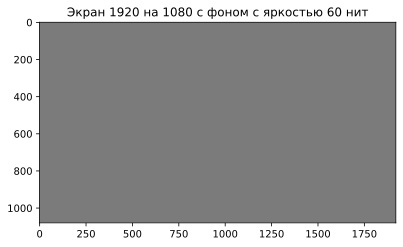

In [9]:
screen_L = np.full((1080, 1920), fill_value=60.0, dtype=np.float32)

screen_rgb = converter.L_to_gray(screen_L)

plt.imshow(screen_rgb, interpolation='nearest', cmap='gray', vmin=0, vmax=255)

plt.title('Экран 1920 на 1080 с фоном с яркостью 60 нит')

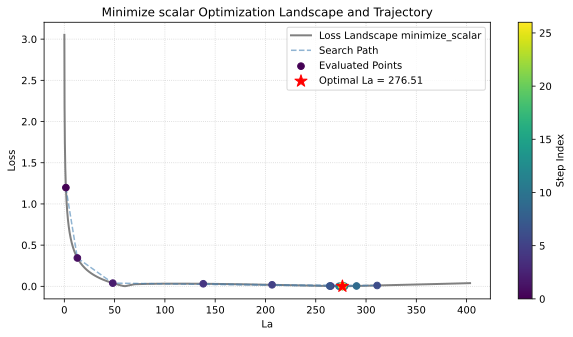

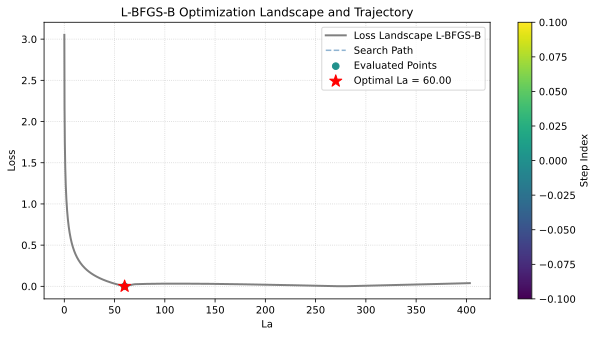

mode: abs
La (minimize scalar): 276.50654739645074
La (log grid search): 276.33713436715095
La (L-BFGS-B): 59.999999999999986


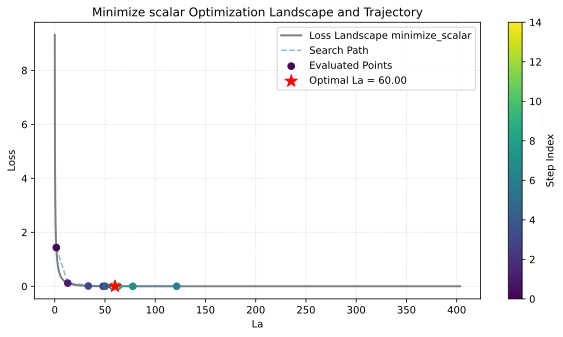

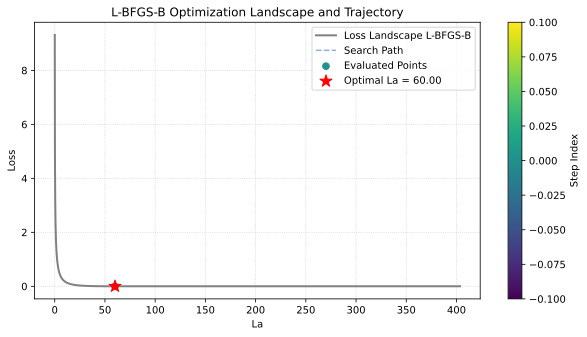

mode: square
La (minimize scalar): 59.99999554541257
La (log grid search): 276.33713436715095
La (L-BFGS-B): 59.999999999999986


In [10]:
jnd_model.find_La_with_background(L_patch=np.array([]), optimizer='log_grid_search', mode='abs')
La_log_grid_search = jnd_model.La

jnd_model.find_La_with_background(L_patch=np.array([]), optimizer='minimize_scalar', mode='abs')
La_minimize_scalar = jnd_model.La

jnd_model.find_La_with_background(L_patch=np.array([]), optimizer='L-BFGS-B', mode='abs')
La_LBFGSB = jnd_model.La

print(f'mode: abs\nLa (minimize scalar): {La_minimize_scalar}\nLa (log grid search): {La_log_grid_search}\nLa (L-BFGS-B): {La_LBFGSB}')

jnd_model.find_La_with_background(L_patch=np.array([]), optimizer='log_grid_search', mode='square')
La_log_grid_search = jnd_model.La

jnd_model.find_La_with_background(L_patch=np.array([]), optimizer='minimize_scalar', mode='square')
La_minimize_scalar = jnd_model.La

jnd_model.find_La_with_background(L_patch=np.array([]), optimizer='L-BFGS-B', mode='square')
La_LBFGSB = jnd_model.La

print(f'mode: square\nLa (minimize scalar): {La_minimize_scalar}\nLa (log grid search): {La_log_grid_search}\nLa (L-BFGS-B): {La_LBFGSB}')

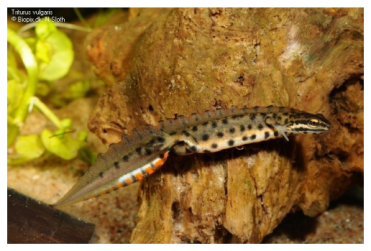

Средняя яркость картинки: 57.409007197578156


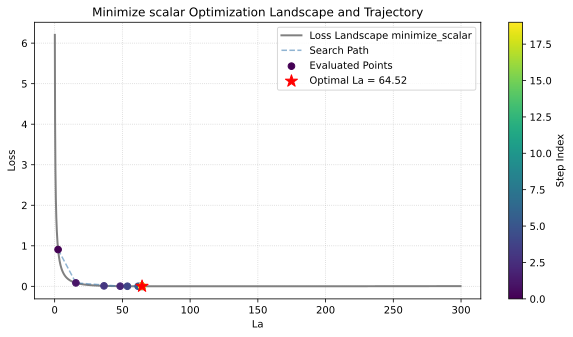

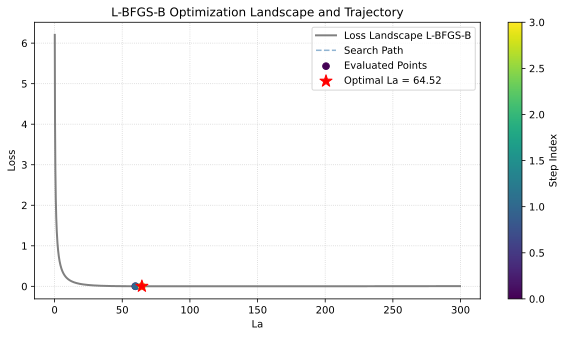

mode = square
Target size: None
La (minimize scalar): 64.51853175838576, t = 8.0172s
La (log grid search): 145.98147420401196, t = 25.2760s
La (L-BFGS-B): 64.51684244160374, t = 6.9306s
Phi: 0.00036896697738272584



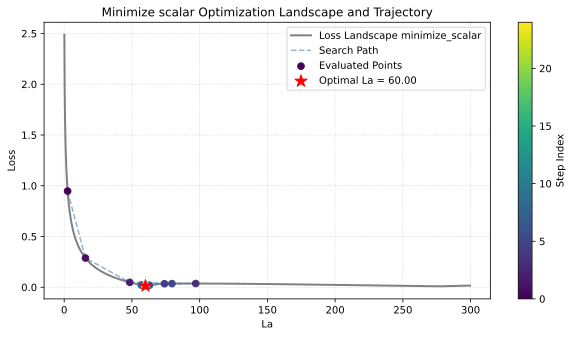

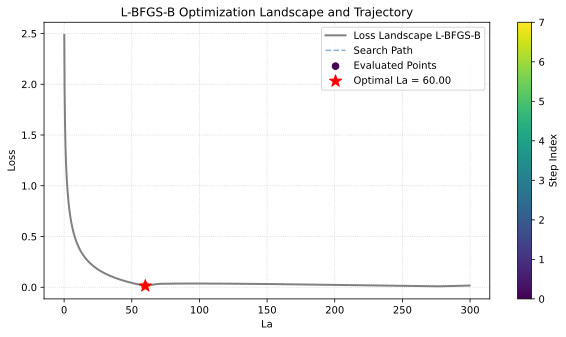

mode = abs
Target size: None
La (minimize scalar): 59.999991042938944, t = 7.7383s
La (log grid search): 275.18829536717755, t = 21.4279s
La (L-BFGS-B): 59.99999972171507, t = 8.9641s
Phi: 0.00036896697738272584



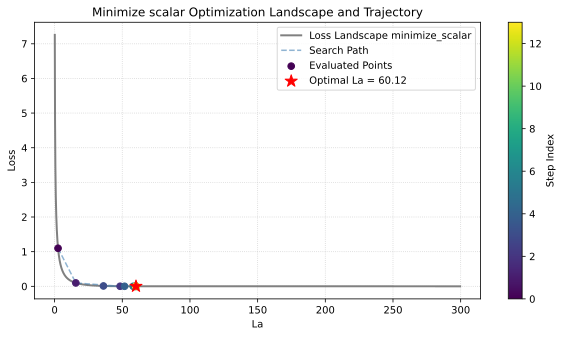

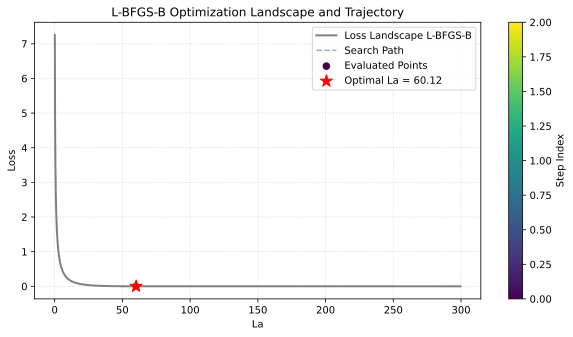

mode = square
Target size: 2
La (minimize scalar): 60.120323330662316, t = 6.5710s
La (log grid search): 60.001361479293415, t = 21.2135s
La (L-BFGS-B): 60.120218584352024, t = 6.3907s
Phi: 6.226317743333499e-05



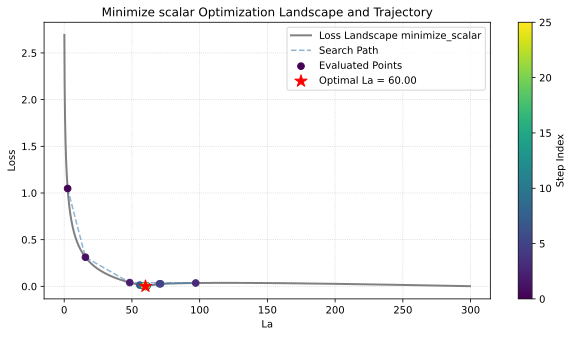

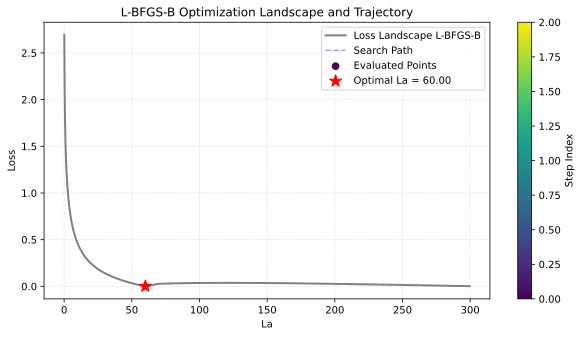

mode = abs
Target size: 2
La (minimize scalar): 59.99999581677687, t = 7.2365s
La (log grid search): 60.001361479293415, t = 20.2759s
La (L-BFGS-B): 59.999999827133465, t = 8.1961s
Phi: 6.226317743333499e-05



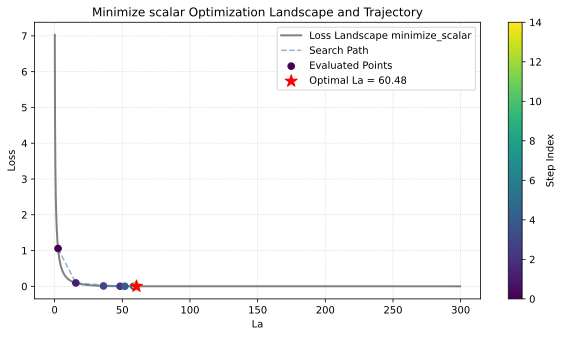

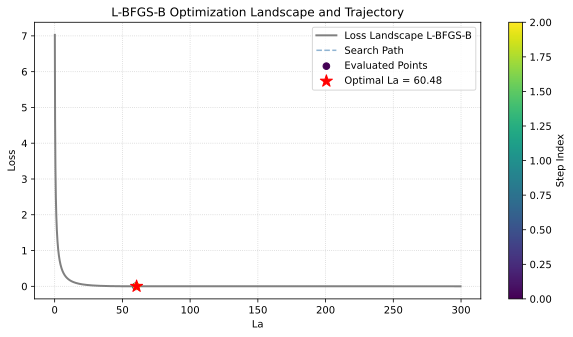

mode = square
Target size: 4
La (minimize scalar): 60.48407009468448, t = 6.4554s
La (log grid search): 60.467054686605145, t = 23.8690s
La (L-BFGS-B): 60.4820200591748, t = 6.6984s
Phi: 0.00012510286576883047



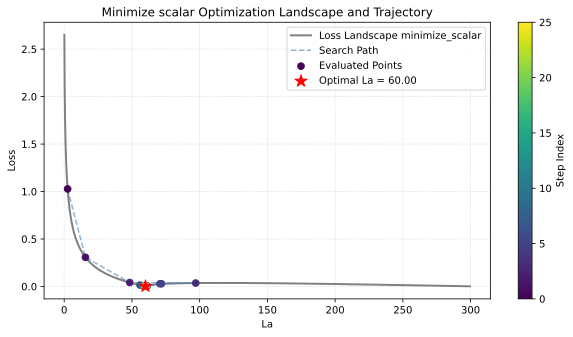

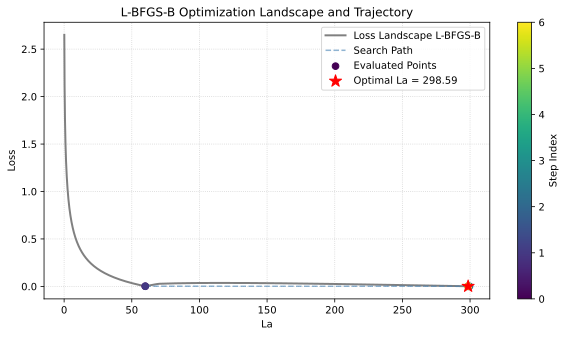

mode = abs
Target size: 4
La (minimize scalar): 59.9999925077353, t = 8.3570s
La (log grid search): 299.61583813774087, t = 23.1356s
La (L-BFGS-B): 298.585451590912, t = 8.1799s
Phi: 0.00012510286576883047



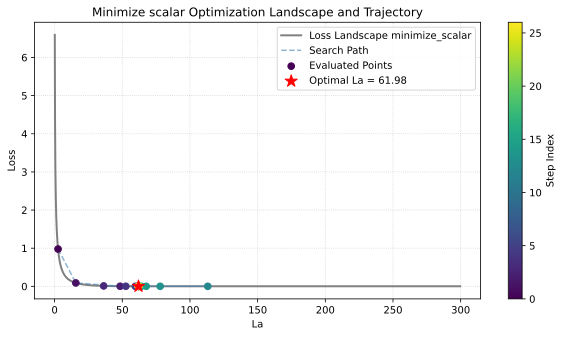

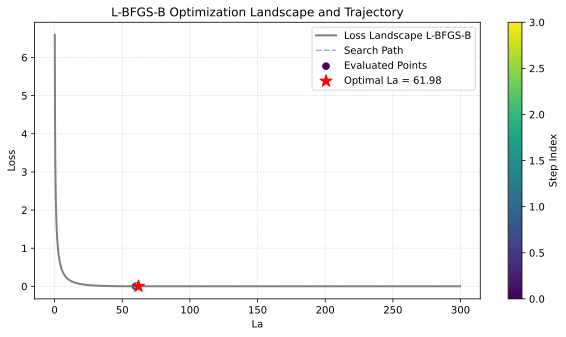

mode = square
Target size: 8
La (minimize scalar): 61.98250290064609, t = 7.1248s
La (log grid search): 192.83031113356876, t = 23.3594s
La (L-BFGS-B): 61.9821094491631, t = 7.2986s
Phi: 0.00025020573153766094



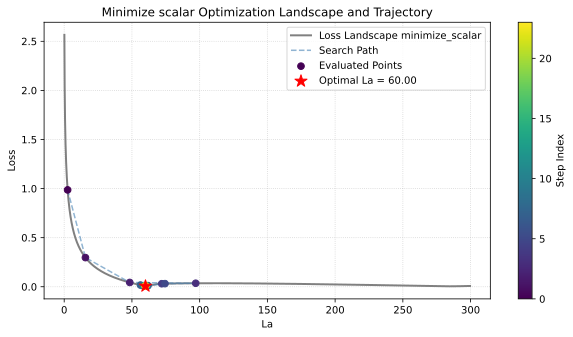

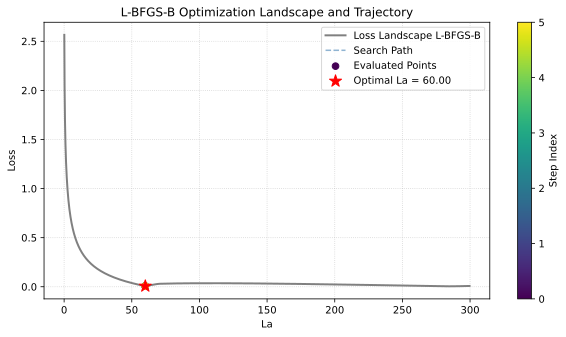

mode = abs
Target size: 8
La (minimize scalar): 60.000006217664506, t = 7.2183s
La (log grid search): 286.0345585919289, t = 20.0530s
La (L-BFGS-B): 59.99999988416486, t = 8.7787s
Phi: 0.00025020573153766094



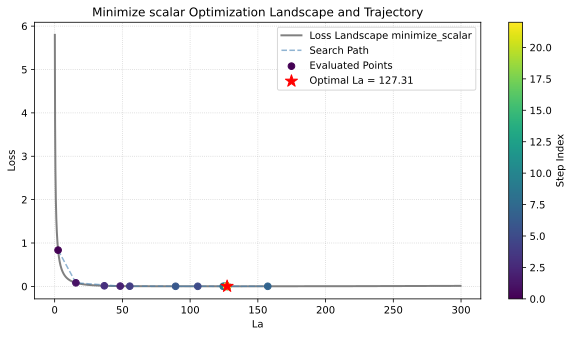

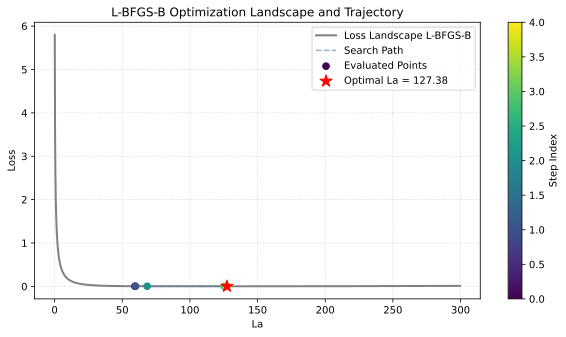

mode = square
Target size: 16
La (minimize scalar): 127.30733666952757, t = 6.9129s
La (log grid search): 127.01615642906394, t = 20.5728s
La (L-BFGS-B): 127.38272216272742, t = 6.7165s
Phi: 0.0004998349521731614



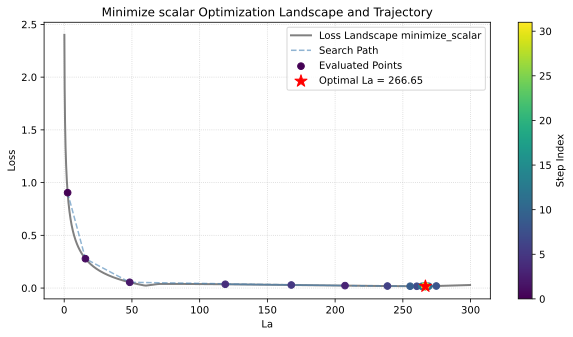

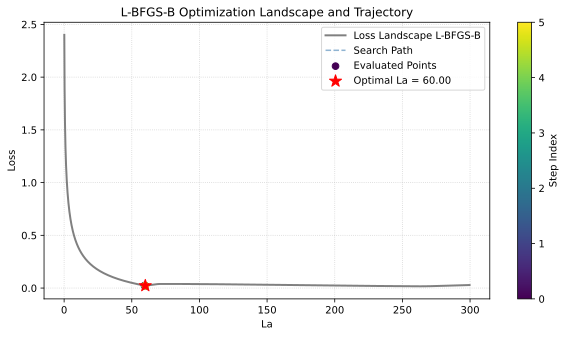

mode = abs
Target size: 16
La (minimize scalar): 266.6491568993223, t = 6.9235s
La (log grid search): 266.8081664904754, t = 20.8931s
La (L-BFGS-B): 59.99999994217589, t = 7.4136s
Phi: 0.0004998349521731614



In [11]:
image_path = '../examples/tiny-imagenet_2.jpg'

pil_image = Image.open(image_path).convert('RGB')

plt.imshow(pil_image)
plt.axis('off')
plt.show()

np_image = np.array(pil_image)

xyzL_image = converter.RGB_to_xyzL(np_image)
L_patch = xyzL_image[..., -1]
print(f"Средняя яркость картинки: {np.mean(L_patch)}")

for target_width_cm in [None, 2, 4, 8, 16]:
    t = time.time()
    jnd_model.find_La_with_background(L_patch=L_patch, optimizer='log_grid_search', target_width_cm=target_width_cm, mode='square')
    La_log_grid_search = jnd_model.La
    t1 = time.time() - t

    t = time.time()
    jnd_model.find_La_with_background(L_patch=L_patch, optimizer='minimize_scalar', target_width_cm=target_width_cm, mode='square')
    La_minimize_scalar = jnd_model.La
    t2 = time.time() - t

    t = time.time()
    jnd_model.find_La_with_background(L_patch=L_patch, optimizer='L-BFGS-B', target_width_cm=target_width_cm, mode='square')
    La_LBFGSB = jnd_model.La
    t3 = time.time() - t

    print(
        'mode = square'
        f'\nTarget size: {target_width_cm}'
        f'\nLa (minimize scalar): {La_minimize_scalar}, t = {t2:.4f}s'
        f'\nLa (log grid search): {La_log_grid_search}, t = {t1:.4f}s'
        f'\nLa (L-BFGS-B): {La_LBFGSB}, t = {t3:.4f}s'
        f'\nPhi: {jnd_model.phi}'
    )
    print()

    t = time.time()
    jnd_model.find_La_with_background(L_patch=L_patch, optimizer='log_grid_search', target_width_cm=target_width_cm, mode='abs')
    La_log_grid_search = jnd_model.La
    t1 = time.time() - t

    t = time.time()
    jnd_model.find_La_with_background(L_patch=L_patch, optimizer='minimize_scalar', target_width_cm=target_width_cm, mode='abs')
    La_minimize_scalar = jnd_model.La
    t2 = time.time() - t

    t = time.time()
    jnd_model.find_La_with_background(L_patch=L_patch, optimizer='L-BFGS-B', target_width_cm=target_width_cm, mode='abs')
    La_LBFGSB = jnd_model.La
    t3 = time.time() - t

    print(
        'mode = abs'
        f'\nTarget size: {target_width_cm}'
        f'\nLa (minimize scalar): {La_minimize_scalar}, t = {t2:.4f}s'
        f'\nLa (log grid search): {La_log_grid_search}, t = {t1:.4f}s'
        f'\nLa (L-BFGS-B): {La_LBFGSB}, t = {t3:.4f}s'
        f'\nPhi: {jnd_model.phi}'
    )
    print()